<a href="https://colab.research.google.com/github/SauravSG/Deep-Learning/blob/main/CIFAR_10_with_WandB_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CIFAR-10**

**CIFAR-10** dataset consist of 60,000, 32x32 images comprises of 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck)

Out of 60,000:

50,000 is Training data.

10,000 is Testing data.

Since CIFAR-10 is a built-in torchvision dataset stored as binary files
(not as folders organized by class), we use the CIFAR10() class directly
instead of ImageFolder. ImageFolder is only needed when you have your own
images organized in class-named folders.

In [1]:
# Let's first import neccessary libraries

import torch
from torch import nn
from torchvision.datasets import CIFAR10

In [2]:
# let's transform the incoming images
'''
Note: We don't need to resize the images to 64x64 as the images in the dataset are already in 32x32. We can skip the transforms.Resize(size=(64x64)) part
'''

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

In [3]:
# we'll need to get the dataset somewhere

train_data = CIFAR10(root = './data',
                     train = True,
                     transform = train_transform,
                     target_transform = None,
                     download = True)

test_data = CIFAR10(root = './data',
                    train = False,
                    transform = test_transform,
                    target_transform = None,
                    download = True)

train_data, test_data

'''
Almost — but it's slightly broader than just loss functions. The fuller version:
target_transform is needed when anything downstream expects targets in a different format than plain integers — that could be:

the loss function (e.g. BCELoss needs one-hot)
the model output format (e.g. multi-label)
'''

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


"\nAlmost — but it's slightly broader than just loss functions. The fuller version:\ntarget_transform is needed when anything downstream expects targets in a different format than plain integers — that could be:\n\nthe loss function (e.g. BCELoss needs one-hot)\nthe model output format (e.g. multi-label)\n"

In [4]:
train_data.classes # gives the all classes names in the dataset

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [5]:
train_data.class_to_idx # the index value of each class

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [6]:
train_data.targets[:10] # printing the first 10 targets

[6, 9, 9, 4, 1, 1, 2, 7, 8, 3]

In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img, label = train_data[0]


In [8]:
img.shape, label

(torch.Size([3, 32, 32]), 6)

In [9]:
newimg = img.permute(1,2,0)
newimg.shape

torch.Size([32, 32, 3])

6


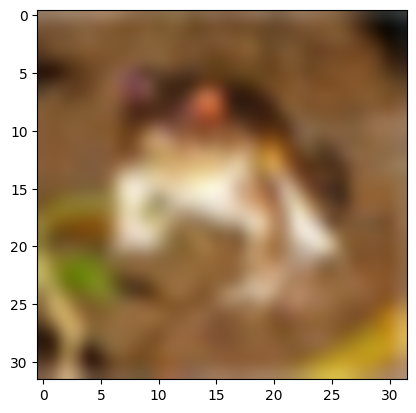

In [10]:
print(label)
plt.imshow(newimg, interpolation = 'bicubic') # -> added interpolation to convert very pixelated image to a bit smoother one

In [11]:
# We can directly jump to to DataLoader as it is not needed to convert the data into dataset

import os

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True,
                              num_workers = NUM_WORKERS)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = False,
                             num_workers = NUM_WORKERS)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7a49a56f08c0>,
 <torch.utils.data.dataloader.DataLoader at 0x7a49a58fc500>)

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [13]:
!pip install wandb

In [14]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: saurav071299 (saurav071299-self) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [27]:
# Let's create model class - a TinyVGG look-a-like mdoel

class TinyVGGV0(nn.Module):

  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):

    super().__init__()

    self.layer_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.layer_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units*8*8,
        out_features = output_shape)
    )

  def forward(self, x):
    x = self.layer_block_1(x)
    #print(f'shape of x after 1st block: {x.shape}')
    x = self.layer_block_2(x)
    #print(f'shape of x after 2nd block: {x.shape}')
    x = self.classifier(x)
    #print(f'shape of x after classifier: {x.shape}')
    return x

In [28]:
model_0 = TinyVGGV0(input_shape=3,
                    hidden_units = 32,
                    output_shape = len(train_data.classes)).to(device)

model_0

TinyVGGV0(
  (layer_block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=10, bias=True)
  )
)

In [29]:
import wandb
run = wandb.init(project='cifar1- with wandb', config = {'lr':0.001, 'batch_size':32, 'epochs':50})
wandb.watch(model_0, log='all')

In [30]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

In [31]:
from torchinfo import summary

summary(model_0, input_size = [32,3,32,32])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGGV0                                [32, 10]                  --
├─Sequential: 1-1                        [32, 32, 16, 16]          --
│    └─Conv2d: 2-1                       [32, 32, 32, 32]          896
│    └─ReLU: 2-2                         [32, 32, 32, 32]          --
│    └─Conv2d: 2-3                       [32, 32, 32, 32]          9,248
│    └─ReLU: 2-4                         [32, 32, 32, 32]          --
│    └─MaxPool2d: 2-5                    [32, 32, 16, 16]          --
├─Sequential: 1-2                        [32, 32, 8, 8]            --
│    └─Conv2d: 2-6                       [32, 32, 16, 16]          9,248
│    └─ReLU: 2-7                         [32, 32, 16, 16]          --
│    └─Conv2d: 2-8                       [32, 32, 16, 16]          9,248
│    └─ReLU: 2-9                         [32, 32, 16, 16]          --
│    └─MaxPool2d: 2-10                   [32, 32, 8, 8]            --
├─Seq

In [32]:
# Before training let's keep loss function and optimizer ready

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(), lr = 0.001)

In [33]:
# Building training and testing loops

def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn = loss_fn,
               optimizer = optimizer,
               device = device):

  # start the training by putting the model into training mode
  model.train()

   # to accumulate the training loss and training accuracy, we will use the below 2 variables
  train_loss, train_acc = 0, 0

  for batch, (X_train,y_train) in enumerate(dataloader): # for batch no. loop through the dataloader to get the img (x) and label (y)

    # put the image and label on the right or desired device
    X_train, y_train = X_train.to(device), y_train.to(device)

    # we will do the gradients = 0 so no previous weights or gradients gets accumulated
    optimizer.zero_grad()

    # now we can do the forward pass
    y_train_logits = model(X_train)

    # calculate the loss
    loss = loss_fn(y_train_logits, y_train)
    train_loss += loss.item() # we will use the item() to get the float value rather than the entire tensors of loss values hence we didn't do .item() while calculating loss in order to avoid converting from tensors to float on the go. this would change the result

    # we will convert the logits we got from forward pass to the labels so we can check the accuracy between the predicted and actual labels
    y_train_labels = torch.argmax(y_train_logits, dim = 1)

    # on the go we will calculate the accuracy as well
    accuracy = ((y_train_labels == y_train).sum().item()/len(y_train_logits))
    train_acc += accuracy

    # loss backward
    loss.backward()

    # once we find the weights that needs to updated, we will update those using step
    optimizer.step()

  # let's calculate the average loss and accuracy over the training once all batches are done
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  return train_loss, train_acc


In [34]:
# Building testing loop function
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn = loss_fn,
              device = device):

  # once above are set, let's put the model in evaluation mode
  model.eval()

  # initializing test loss and accuracy variables to accumulate the loss and accuracy over the training and then calculating the average at the end
  test_loss, test_acc = 0, 0



  with torch.inference_mode():

    # define the batch, image and label loop
    for batch, (X_test, y_test) in enumerate(dataloader):

      # moving the test image and test label to the target device
      X_test, y_test = X_test.to(device), y_test.to(device)

      # forward pass. We will not do optimizer zero grad as we are not aiming for training hence we dont need to accumate the gradients
      y_test_logits = model(X_test)

      # calculate the loss
      loss = loss_fn(y_test_logits, y_test)
      test_loss += loss.item() # -> better to itemize here so we can convert the total loss tensor value to float value

      # let's convert the y_test_logits to labels
      y_test_labels = torch.argmax(y_test_logits, dim=1)

      # let's calculate accuracy
      acc = ((y_test_labels == y_test).sum().item()/len(y_test_logits))
      # here we are basically checking how many true boolean values we get, then we sum it and convert the sum number to a plain python value and divind this to the len og the test logits over the batch

      test_acc += acc

  test_loss /= len(dataloader)
  test_acc /= len(dataloader)

  return test_loss, test_acc



In [35]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

import wandb

# let's build a train function to make the train and test function work
def train(model: torch.nn.Module,
          trainDataLoader: torch.utils.data.DataLoader,
          testDataLoader: torch.utils.data.DataLoader,
          run: wandb,
          loss_fn = loss_fn,
          optimizer = optimizer,
          device=device):

  results = {
      'train_loss': [],
      'train_acc': [],
      'test_loss': [],
      'test_acc': []
  }
  epochs = run.config.epochs
  for epoch in range(epochs):

    train_loss, train_acc = train_step(model = model,
                                       dataloader = trainDataLoader,
                                       loss_fn = loss_fn,
                                       optimizer = optimizer,
                                       device = device)

    test_loss, test_acc = test_step(model = model,
                                    dataloader = testDataLoader,
                                    loss_fn = loss_fn,
                                    device = device)


    # print(f'epochs: {epoch} | train loss: {train_loss:.4f} | train_acc: {train_acc:.2f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.2f}')

    wandb.log({'epochs': epoch,
               'train_loss': train_loss,
               'train_acc': train_acc,
               'test_loss': test_loss,
               'test_acc': test_acc})

    results['train_loss'].append(train_loss)
    results['train_acc'].append(train_acc)
    results['test_loss'].append(test_loss)
    results['test_acc'].append(test_acc)


  return results



In [36]:
model_0_results = train(model = model_0,
                         trainDataLoader = train_dataloader,
                         testDataLoader = test_dataloader,
                         run = run,
                         loss_fn = loss_fn,
                         optimizer = optimizer,
                         device = device)


wandb.finish()
model_0_results

epochs,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
test_acc,▁▄▅▆▆▇▇▇▇██████████████▇▇█████████████▇█
test_loss,█▅▄▃▃▂▂▂▁▁▁▁▁▁▁▂▁▁▁▁▂▂▂▂▂▁▂▂▂▂▂▂▂▂▂▂▃▂▃▂
train_acc,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████████
train_loss,█▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epochs,49
test_acc,0.75679
test_loss,0.80265
train_acc,0.85133
train_loss,0.4199


{'train_loss': [1.505838334255316,
  1.1025314384443365,
  0.9509806326010711,
  0.8619368371678253,
  0.8011182012728827,
  0.7562684127900056,
  0.7221104731581871,
  0.7003164624107701,
  0.675003504970481,
  0.6531852709793236,
  0.6368354122682939,
  0.6213305542866389,
  0.6112927042915511,
  0.6004074467292445,
  0.5907115651221895,
  0.5765891467445718,
  0.5667986079850261,
  0.561840933948393,
  0.552935300360333,
  0.5414793417382072,
  0.5381701246752467,
  0.5301030463064167,
  0.527377574272592,
  0.5224235066697145,
  0.520178204734815,
  0.5074730086845232,
  0.5057530427638797,
  0.49883168244106374,
  0.4930900632095733,
  0.48512793226037665,
  0.48568080389492035,
  0.47885870432060496,
  0.47136846294844675,
  0.4652072209066408,
  0.4659814377501845,
  0.4625645742363756,
  0.45573435183697913,
  0.4543631121049077,
  0.4499356680748101,
  0.44331365106335374,
  0.4395568045052823,
  0.43788249054667433,
  0.4338980154613997,
  0.4346184345559287,
  0.431588626015

In [37]:
def plot_curve(results):

  plt.figure(figsize=(7, 7))

  plt.subplot(1, 2, 1)
  plt.plot(results['train_loss'], label = 'train_loss')
  plt.plot(results['test_loss'], label = 'test_loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(results['train_acc'], label = 'train_acc')
  plt.plot(results['test_acc'], label = 'test_acc')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.show()

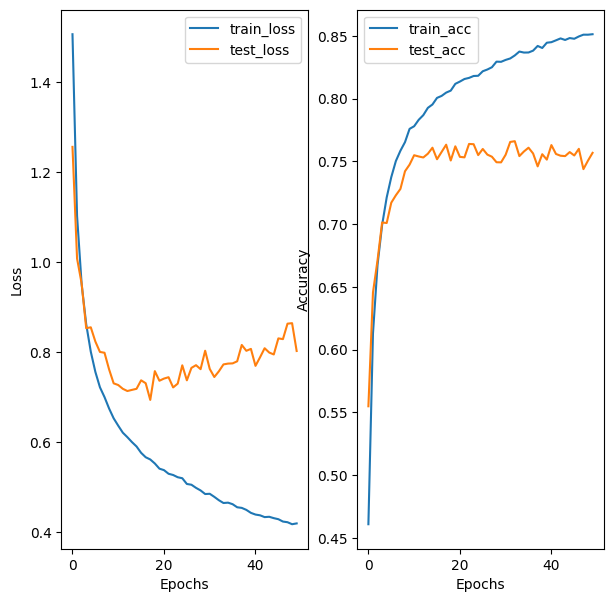

In [38]:
plot_curve(model_0_results)

## W&B Learning And Insights

*What W&B is and why it exists
One paragraph. What problem it solves, what it stores, and what the dashboard lets you do that a notebook cannot.*

W&B is a library as a well as a platform which leverages the ability to see the model's performances for different hyperparameters. Not just this, it also provides the line graphs, histographs, curves etc about the overall training and testing epochs. Unlike notebook, each training testing session is saved in the W&B dashboard by different run IDs. Run ID/Run is the unit of logged executions.

It stores the info about which hyperparameter along with what values were used for specific training testing sessions and because of the dashboard we can easily take a quick look into the performance and which ever run session gave better result with no caveats, we can easily move it to the projects or groups.

This gives the ability to just take a quick look and decide rather than running each session in notebook just to see how the model is performing.

*How it plugs into a training loop
The five lines — wandb.init, wandb.watch, wandb.log, wandb.finish — and for each one, one sentence on what it does and exactly where in the loop it lives.*

W&B's `wandb` has 4 main methods that are heavily used during the sessions.

[In order]
Before all these 4 methods, we need to install and login into wandb:

For installing:
 > !pip install wandb

For login:
 > !wandb login -> here it asks for api key and also provide the URL to get the api key from.

1. `wandb.init()` is a method which we use before the model's instance is created. It is use to initialise the run for the model. So, here we need to give a project name and also define `config`. Config plays a significant role because it easily allows us to define the hyperparameters and there values. `config` is eventually makes the hyperparameters column in the dashboard's run section where it logs what values for those hyperparameters were used.

2. `wand.watch()` is defined right after the model is created and as from this point we ask wandb to keep an eye on the sessions. It tracks the gradients and parameters and display these in histograms.

3. `wandb.log()` is use to log the metrics like the loss and accuracy for every epoch. It just doesn't log these metrics but also shows the entire flow in form line curves which gives more insights to see how the training went, any signs of overfitting/underfitting etc. It is called once per epoch after the training and testing has return there average values.

4. `wandb.finish()` is the placed at the end of the complete training testing session as a way to finish the session.

Here: https://wandb.ai/saurav071299-self/cifar1-%20with%20wandb/runs/f1186pen?nw=nwusersaurav071299


## Model's performance insight:

Looking at out model's result, we can see that the model was working well till epoch 15 to 20 and then we can see the divergence. It is the sign of `overfitting` where the model is learning too good or more like memorising but the test loss is increasing after one point.